In [82]:
import pandas as pd
import numpy as np
import datetime

df = pd.read_csv('/content/AB_NYC.csv')

np.random.seed(0)
df.head()

,Unnamed: 0,id,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,parsed_last_review
0,0,2539,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19 00:00:00.000000000,0.210000,6,365,2018-10-19 00:00:00.000000000
1,1,2595,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21 00:00:00.000000000,0.380000,2,355,2019-05-21 00:00:00.000000000
2,2,3647,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,2018-10-04 01:47:23.910099456,1.373221,1,365,2018-10-04 01:47:23.910099456
3,3,3831,4869,Lisaroxanne,Brooklyn,Clinton hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05 00:00:00.000000000,4.640000,1,194,2019-07-05 00:00:00.000000000
4,4,5022,7192,Laura,Manhattan,East harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19 00:00:00.000000000,0.100000,1,0,2018-11-19 00:00:00.000000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [5]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [21]:
# parsing date
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

In [24]:
# filling missing values
missing_names = ['name', 'host_name']
df[missing_names] = df[missing_names].fillna('Unknown')
missing_reviews = ['last_review', 'reviews_per_month']
df[missing_reviews]= df[missing_reviews].fillna(df[missing_reviews].mean())

In [25]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [26]:
df.duplicated().sum()

np.int64(0)

In [33]:
names = df['name'].unique()
names.sort()
names

array([' 1 Bed Apt in Utopic Williamsburg ',
       ' 2-3 bedroom UWS garden triplex ',
       ' 3 bedroom loft in Williamsburg', ...,
       '️CENTRALLY LOCATED️- Great for Families + Groups',
       'ｳｨﾘｱﾑｽﾞﾊﾞｰｸﾞのかわいいお部屋です2',
       'ﾏﾝﾊｯﾀﾝ､駅から徒歩4分でどこに行くのにも便利な場所!女性の方希望,ｷﾚｲなお部屋｡'], dtype=object)

In [44]:
df = df.drop('name', axis=1)


In [46]:
names = df['host_name'].unique()
names.sort()
names

array(["'Cil", '(Ari) HENRY LEE', '(Email hidden by Airbnb)', ..., '소정',
       '진', '현선'], dtype=object)

In [53]:
df['host_name']= df['host_name'].str.lower()
df['host_name']= df['host_name'].str.strip()
df['host_name'] = df['host_name'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)

In [55]:
df['host_name'] = df['host_name'].apply(lambda x: x.encode('ascii', 'ignore').decode('ascii'))

In [56]:
names = df['host_name'].unique()
names.sort()
names


array(['', '  fredy', ' art house monique', ..., 'zyad', 'zyanna',
       'zyanya'], dtype=object)

In [65]:
# !pip install fuzzywuzzy
import fuzzywuzzy
from fuzzywuzzy import process
matches = fuzzywuzzy.process.extract("zyanna", names, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio)

matches

/usr/local/lib/python3.12/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


[('zyanna', 100),
 ('yanna', 91),
 ('ayanna', 83),
 ('dyanna', 83),
 ('yanina', 83),
 ('yoanna', 83),
 ('zhanna', 83),
 ('zyanya', 83),
 ('anna', 80),
 ('yana', 80)]

In [67]:
df['host_name']= df['host_name'].str.capitalize()

In [68]:
neighbourhood_groups = df['neighbourhood_group'].unique()
neighbourhood_groups.sort()
neighbourhood_groups

array(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'],
      dtype=object)

In [69]:
neighbourhoods = df['neighbourhood'].unique()
neighbourhoods.sort()
neighbourhoods

array(['Allerton', 'Arden Heights', 'Arrochar', 'Arverne', 'Astoria',
       'Bath Beach', 'Battery Park City', 'Bay Ridge', 'Bay Terrace',
       'Bay Terrace, Staten Island', 'Baychester', 'Bayside', 'Bayswater',
       'Bedford-Stuyvesant', 'Belle Harbor', 'Bellerose', 'Belmont',
       'Bensonhurst', 'Bergen Beach', 'Boerum Hill', 'Borough Park',
       'Breezy Point', 'Briarwood', 'Brighton Beach', 'Bronxdale',
       'Brooklyn Heights', 'Brownsville', "Bull's Head", 'Bushwick',
       'Cambria Heights', 'Canarsie', 'Carroll Gardens', 'Castle Hill',
       'Castleton Corners', 'Chelsea', 'Chinatown', 'City Island',
       'Civic Center', 'Claremont Village', 'Clason Point', 'Clifton',
       'Clinton Hill', 'Co-op City', 'Cobble Hill', 'College Point',
       'Columbia St', 'Concord', 'Concourse', 'Concourse Village',
       'Coney Island', 'Corona', 'Crown Heights', 'Cypress Hills',
       'DUMBO', 'Ditmars Steinway', 'Dongan Hills', 'Douglaston',
       'Downtown Brooklyn', 'Dyk

In [72]:
df['neighbourhood_group']= df['neighbourhood_group'].str.capitalize()
df['neighbourhood']= df['neighbourhood'].str.capitalize()

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   host_id                         48895 non-null  int64         
 2   host_name                       48895 non-null  object        
 3   neighbourhood_group             48895 non-null  object        
 4   neighbourhood                   48895 non-null  object        
 5   latitude                        48895 non-null  float64       
 6   longitude                       48895 non-null  float64       
 7   room_type                       48895 non-null  object        
 8   price                           48895 non-null  int64         
 9   minimum_nights                  48895 non-null  int64         
 10  number_of_reviews               48895 non-null  int64         
 11  la

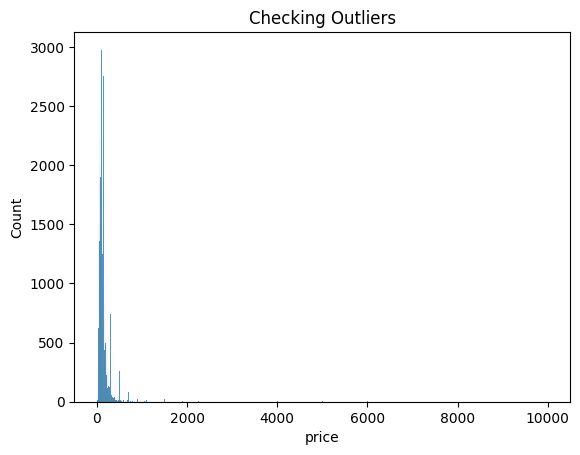

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='price')
plt.title('Checking Outliers')
plt.show()

In [83]:
df.to_csv('/content/AB_NYC.csv', index=False)

In [84]:
df.head()

,Unnamed: 0,id,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,parsed_last_review
0,0,2539,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19 00:00:00.000000000,0.210000,6,365,2018-10-19 00:00:00.000000000
1,1,2595,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21 00:00:00.000000000,0.380000,2,355,2019-05-21 00:00:00.000000000
2,2,3647,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,2018-10-04 01:47:23.910099456,1.373221,1,365,2018-10-04 01:47:23.910099456
3,3,3831,4869,Lisaroxanne,Brooklyn,Clinton hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05 00:00:00.000000000,4.640000,1,194,2019-07-05 00:00:00.000000000
4,4,5022,7192,Laura,Manhattan,East harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19 00:00:00.000000000,0.100000,1,0,2018-11-19 00:00:00.000000000
